In [1]:
import pandas as pd
import os
from table import Table
import json
import matplotlib.pyplot as plt
import seaborn as sns

/media/nas/olayap/env_olaya/Doctorado/representation_LQ/table.py:91: SyntaxWarning: invalid escape sequence '\p'
  whitespace = '$^{\phantom{\dag}}$'
/media/nas/olayap/env_olaya/Doctorado/representation_LQ/table.py:102: SyntaxWarning: invalid escape sequence '\p'
  std = f'$\pm${whitespace}{self.std():.{self.format.std_prec}f}'
/media/nas/olayap/env_olaya/Doctorado/representation_LQ/table.py:117: SyntaxWarning: invalid escape sequence '\d'
  comp_symbol = '$^{\dag}$'
/media/nas/olayap/env_olaya/Doctorado/representation_LQ/table.py:119: SyntaxWarning: invalid escape sequence '\d'
  comp_symbol = '$^{\ddag}$'
/media/nas/olayap/env_olaya/Doctorado/representation_LQ/table.py:228: SyntaxWarning: invalid escape sequence '\c'
  return f'\cellcolor{{{color}!{int(tone)}}}'
/media/nas/olayap/env_olaya/Doctorado/representation_LQ/table.py:418: SyntaxWarning: invalid escape sequence '\m'
  corner = '\multicolumn{1}{c|}{} & '
/media/nas/olayap/env_olaya/Doctorado/representation_LQ/table.py:434: Syn

In [2]:
datasets = ['connect-4', 'dry-bean', 'hand_digits', 'chess', 'shuttle', 'poker_hand']
table_ae = Table(name='mae')
table_rae = Table(name='mrae')

In [3]:
def obtener_val_loss(ruta_archivo):
    """Leer el archivo JSON y obtener el valor de 'val_loss'."""
    with open(ruta_archivo, 'r') as archivo:
        datos = json.load(archivo)
        return datos.get('val_loss', float('inf'))  # Retorna infinito si 'val_loss' no está presente

def comparar_archivos(directorio):
    archivos = os.listdir(directorio)
    archivos_dict = {}
    
    # Recorremos los archivos en el directorio
    for nombre_archivo in archivos:
        if nombre_archivo.endswith('.json'):
            # Dividir el nombre del archivo en la parte base y el sufijo DO0/DO1
            base_nombre = nombre_archivo.rsplit('+', 1)[0]  # Remueve el sufijo DO0/DO1
            sufijo = nombre_archivo[-6:-5]  # Extrae DO0 o DO1
            if base_nombre not in archivos_dict:
                archivos_dict[base_nombre] = {}
            archivos_dict[base_nombre][sufijo] = os.path.join(directorio, nombre_archivo)
    
    # Comparar archivos en pares
    mejores_archivos = []
    for base_nombre, archs in archivos_dict.items():
        if '0' in archs and '1' in archs:
            archivo_do0 = archs['0']
            archivo_do1 = archs['1']
            
            val_loss_do0 = obtener_val_loss(archivo_do0)
            val_loss_do1 = obtener_val_loss(archivo_do1)
            
            # Comparar los valores de 'val_loss' y seleccionar el mejor
            if val_loss_do0 < val_loss_do1:
                mejores_archivos.append(archivo_do0)
            else:
                mejores_archivos.append(archivo_do1)
    return mejores_archivos

In [4]:
def reemplazar_por_simbolos(directorio, nombre_archivo, diccionario_mapeo):
    partes = nombre_archivo[7:].split('+')
    is_PGR0 = 'PGR0' in partes
    is_CM0 = 'CM0' in partes
    is_HIS0 = 'HIS0' in partes
    is_CP0 = 'CP0' in partes
    is_CN0 = 'CN0' in partes
    is_AE0 = 'AE0' in partes
    partes_modificadas = []
    partes_directorio = directorio.strip('/')
    if 'Z' in partes_directorio:
        partes_modificadas.append(r'$\mathcal{L}_Z$')
    for parte in partes:
        if parte in diccionario_mapeo:
            partes_modificadas.append(diccionario_mapeo[parte])
    if is_PGR0 and is_HIS0 or is_CM0 and is_HIS0:
        partes_modificadas.append(r'$\Phi_\mu$')
    if is_CP0 and is_CN0 and is_AE0: 
        partes_modificadas.append(r'$\phi_{\emptyset}$')

    sorted_partes_modificadas = [partes_modificadas[0]]+sorted(partes_modificadas[-2:])
    nombre_modificado = '+'.join(sorted_partes_modificadas)
    return nombre_modificado

In [5]:
diccionario_mapeo = {
    'TRI': r'$\mathcal{L}_T$',
    'QNT': r'$\mathcal{L}_2$',
    'REG': r'$\mathcal{L}_{\text{Mq}}$',
    'ZREG': r'$\mathcal{L}_Z$',
    'CM1': r'$\Phi_{\sum}$',
    '16bHIS1': r'$\Phi_H$',
    'CP1': r'$\phi_h$',
    'CN1': r'$\phi_\ell$',
    'AE1': r'$\phi_A$'
}

In [6]:
directory = 'prueba/'

In [7]:
import numpy as np
for direc in ['Mq/', 'Z/']:
    for d in datasets:
        dir = directory+direc+d
        files_list = comparar_archivos(dir)
        for file_path in files_list: #os.listdir(dir):
            
            with open(file_path, 'r') as f:
                report = json.load(f)
            file = file_path.split('/')[-1:][0]
            df = pd.read_json(file_path)
            aes = df["mae_test"].values
            raes = df["mrae_test"].values
            #parts = file[len(d)+3:-5].split('+')
            method_name = reemplazar_por_simbolos(direc, file, diccionario_mapeo)
            
            table_ae.add(benchmark=d, method=method_name, v=aes)
            table_rae.add(benchmark=d, method=method_name, v=raes)            

methods = table_rae.get_methods()                        
methods_replace = {m:m for m in methods}
Table.LatexPDF(f'./latex/table_phiNN_big.pdf', [table_ae, table_rae], dedicated_pages=False, transpose = True, method_replace=methods_replace)
            

currently in /media/nas/olayap/env_olaya/Doctorado/representation_LQ
[Tables Done] runing latex
This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./table_phiNN_big.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/amsmath/amsmath.sty
For additional information on amsmath, use the `?' option.
(/usr/share/texlive/texmf-dist/tex/latex/amsmath/amstext.sty
(/usr/share/texlive/texmf-dist/tex/latex/amsmath/amsgen.sty))
(/usr/share/texlive/texmf-dist/tex/latex/amsmath/amsbsy.sty)
(/usr/share/texlive/texmf-dist/tex/latex/amsmath/amsopn.sty))
(/usr/share/texlive/texmf-dist/tex/latex/a

# Plots

### AE

In [8]:
data = []

# table_ae
for method in table_ae.get_methods():
    m = method.split('+')
    values = table_ae.get_method_values(method)
    for i, value in enumerate(values):
        data.append({'Benchmark': table_ae.get_benchmarks()[i], 'Loss': m[0], 'Phi': m[1], 'phi': m[2], 'Value': value})

df_data = pd.DataFrame(data)

Radial Plot Loss & Phi and Loss & phi and Phi & phi

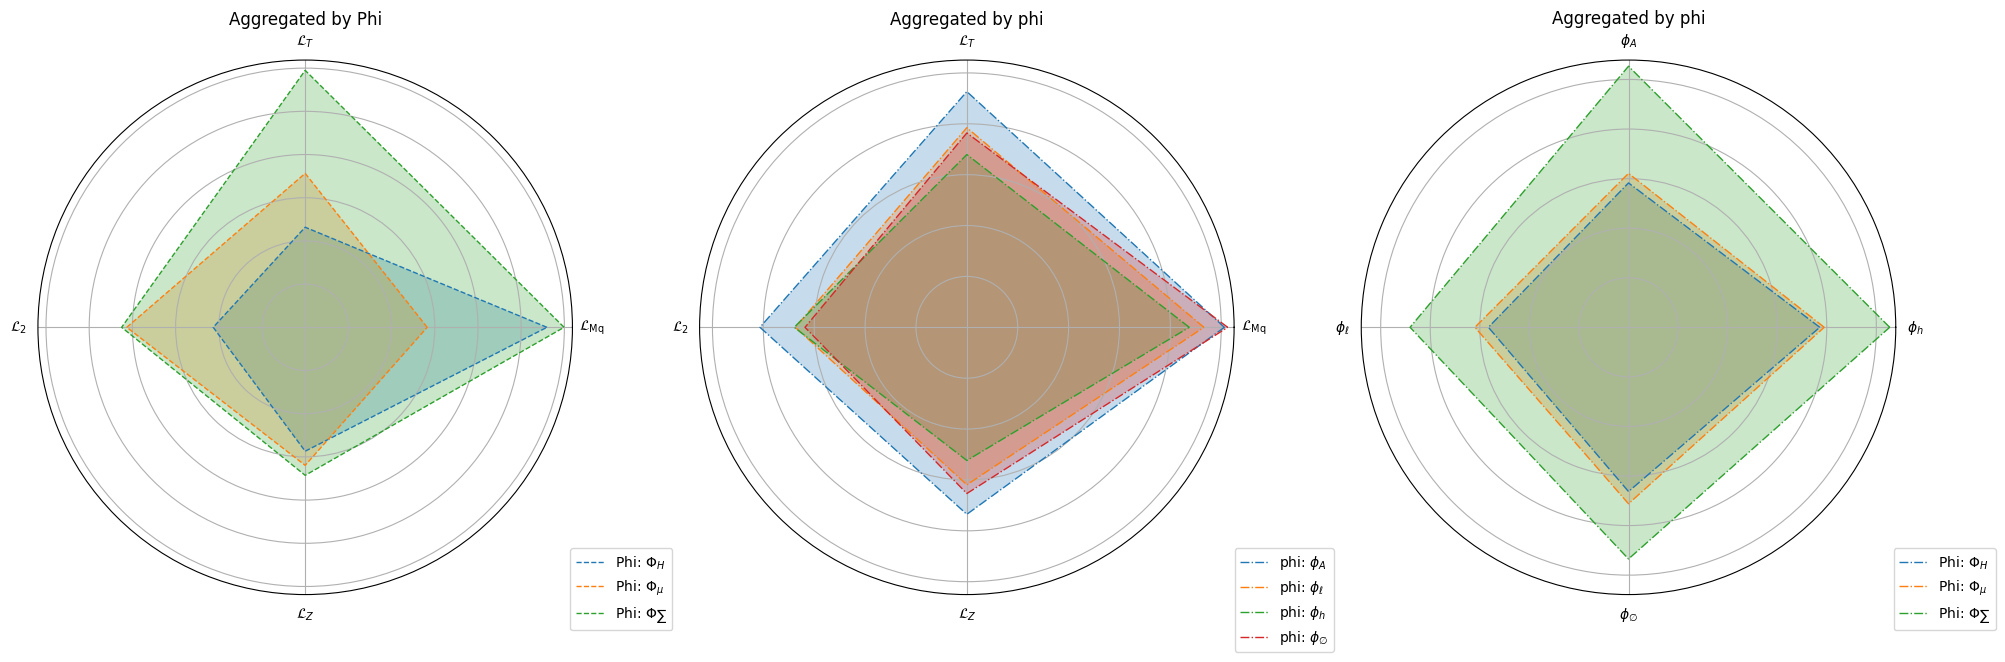

In [9]:
phi_group = df_data.groupby(['Loss', 'Phi'])['Value'].mean().reset_index()
small_phi_group = df_data.groupby(['Loss', 'phi'])['Value'].mean().reset_index()
phis_group = df_data.groupby(['Phi', 'phi'])['Value'].mean().reset_index()


loss = df_data['Loss'].unique()
N = len(loss)

phis = df_data['phi'].unique()

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  

fig, axs = plt.subplots(1, 3, figsize=(20, 8), subplot_kw=dict(polar=True))

for phi in phi_group['Phi'].unique():
    values = phi_group[phi_group['Phi'] == phi]['Value'].tolist()
    values += values[:1]  
    axs[0].plot(angles, values, linewidth=1, linestyle='dashed', label=f'Phi: {phi}')
    axs[0].fill(angles, values, alpha=0.25)
axs[0].set_xticks(angles[:-1])
axs[0].set_xticklabels(loss)
axs[0].set_yticklabels([])
axs[0].set_title('Aggregated by Phi')
axs[0].legend(loc='upper right', bbox_to_anchor=(1.2, 0.1))

for small_phi in small_phi_group['phi'].unique():
    values = small_phi_group[small_phi_group['phi'] == small_phi]['Value'].tolist()
    values += values[:1]  
    axs[1].plot(angles, values, linewidth=1, linestyle='dashdot', label=f'phi: {small_phi}')
    axs[1].fill(angles, values, alpha=0.25)
axs[1].set_xticks(angles[:-1])
axs[1].set_xticklabels(loss)
axs[1].set_yticklabels([])
axs[1].set_title('Aggregated by phi')
axs[1].legend(loc='upper right', bbox_to_anchor=(1.2, 0.1))

for phi_gr in phis_group['Phi'].unique():
    values = phis_group[phis_group['Phi'] == phi_gr]['Value'].tolist()
    values += values[:1]  
    axs[2].plot(angles, values, linewidth=1, linestyle='dashdot', label=f'Phi: {phi_gr}')
    axs[2].fill(angles, values, alpha=0.25)
axs[2].set_xticks(angles[:-1])
axs[2].set_xticklabels(phis)
axs[2].set_yticklabels([])
axs[2].set_title('Aggregated by phi')
axs[2].legend(loc='upper right', bbox_to_anchor=(1.2, 0.1))


plt.tight_layout()
plt.show()


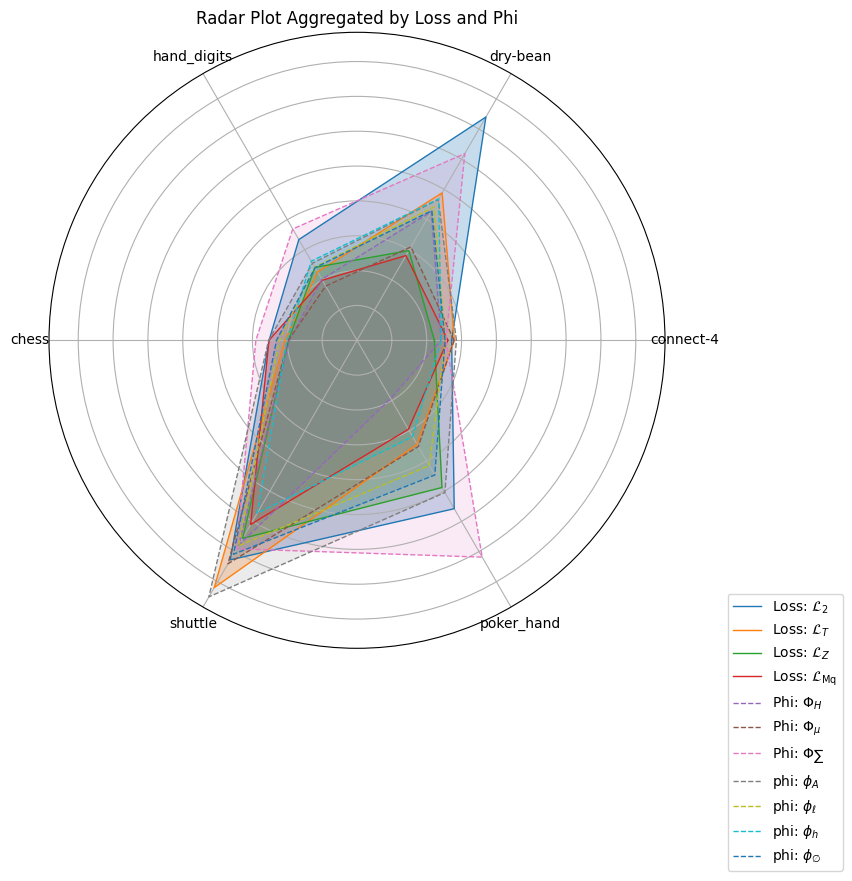

In [10]:
loss_group = df_data.groupby(['Benchmark', 'Loss'])['Value'].mean().reset_index()
phi_gr_group = df_data.groupby(['Benchmark', 'Phi'])['Value'].mean().reset_index()
phi_group = df_data.groupby(['Benchmark', 'phi'])['Value'].mean().reset_index()

benchmarks = df_data['Benchmark'].unique()
N = len(benchmarks)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for loss in loss_group['Loss'].unique():
    values = loss_group[loss_group['Loss'] == loss]['Value'].tolist()
    values += values[:1]  
    ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Loss: {loss}')
    ax.fill(angles, values, alpha=0.25)

for phi_gr in phi_gr_group['Phi'].unique():
    values = phi_gr_group[phi_gr_group['Phi'] == phi_gr]['Value'].tolist()
    values += values[:1]  
    ax.plot(angles, values, linewidth=1, linestyle='dashed', label=f'Phi: {phi_gr}')
    ax.fill(angles, values, alpha=0.15)

for phi in phi_group['phi'].unique():
    values = phi_group[phi_group['phi'] == phi]['Value'].tolist()
    values += values[:1]  
    ax.plot(angles, values, linewidth=1, linestyle='dashed', label=f'phi: {phi}')
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(benchmarks)

ax.set_yticklabels([])

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 0.1))

plt.title('Radar Plot Aggregated by Loss and Phi')

plt.show()


Loss

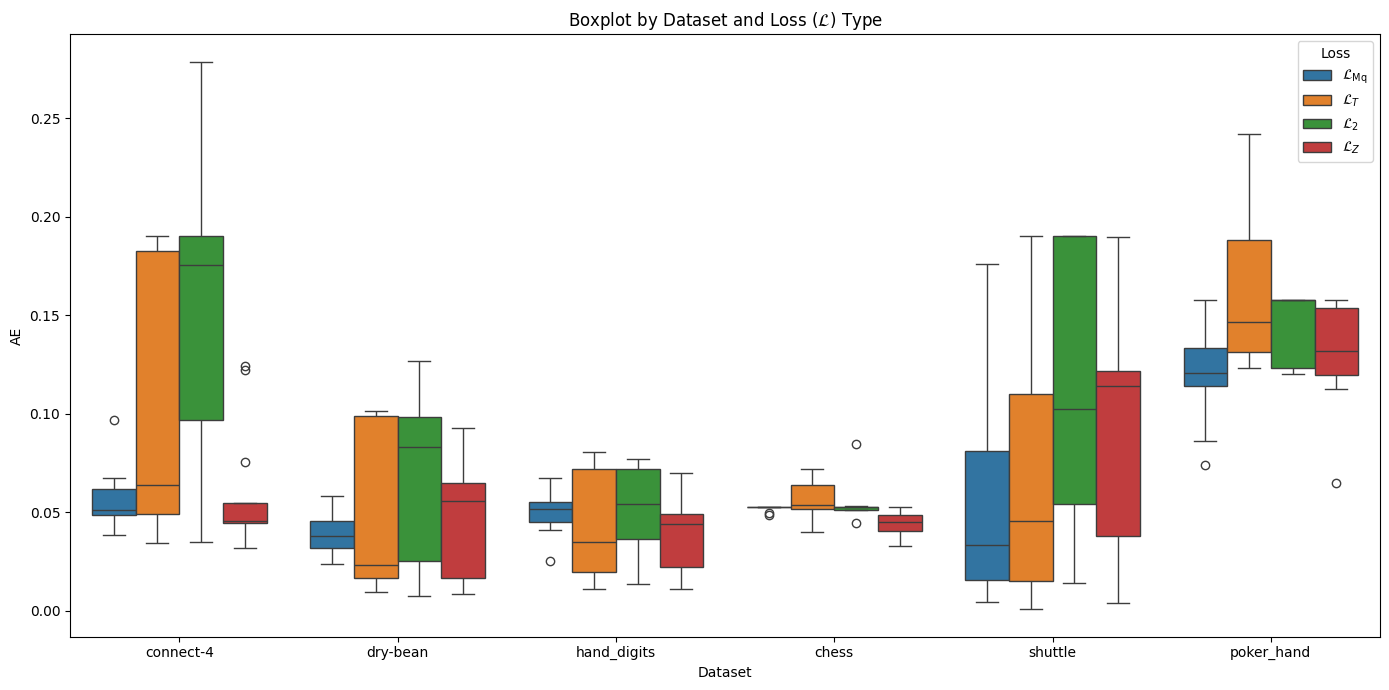

In [11]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='Benchmark', y='Value', hue='Loss', data=df_data)
plt.title(r'Boxplot by Dataset and Loss ($\mathcal{L}$) Type')
plt.xlabel('Dataset')
plt.ylabel('AE')
plt.tight_layout()
plt.show()

Phi

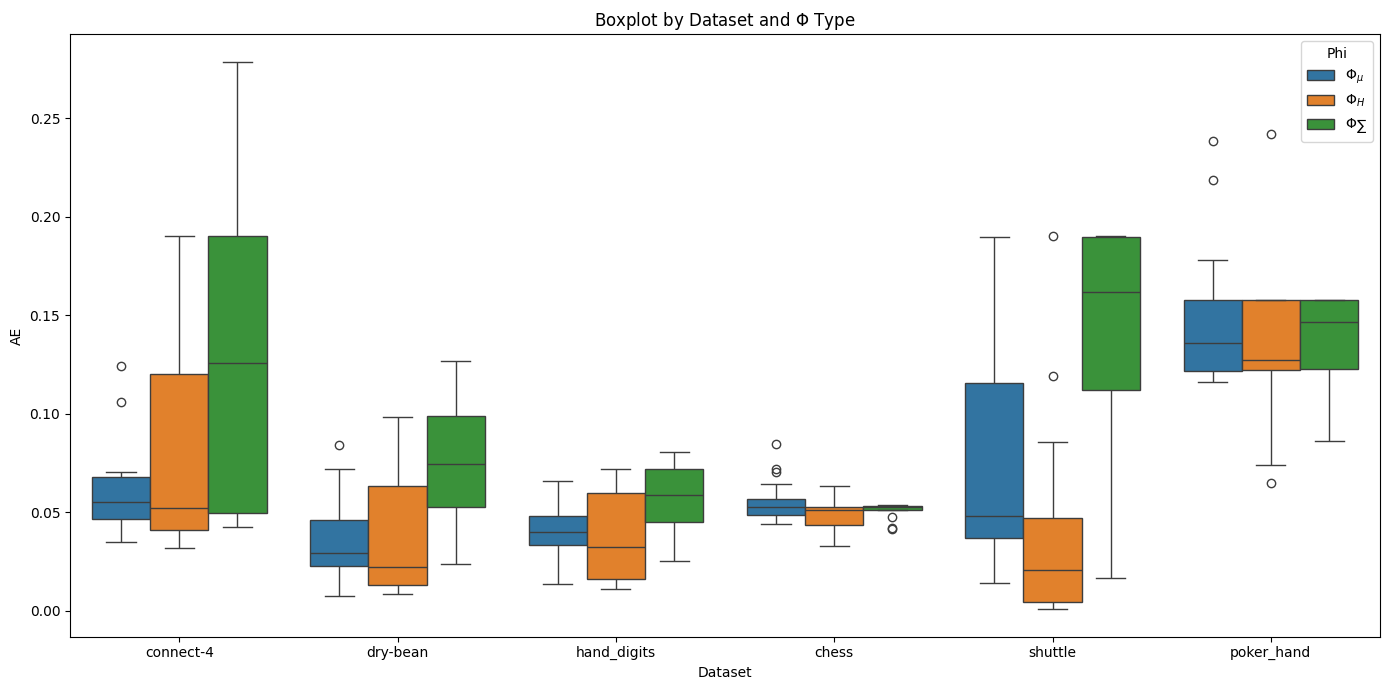

In [12]:

plt.figure(figsize=(14, 7))
sns.boxplot(x='Benchmark', y='Value', hue='Phi', data=df_data)
plt.title(r'Boxplot by Dataset and $\Phi$ Type')
plt.xlabel('Dataset')
plt.ylabel('AE')
plt.tight_layout()
plt.show()

phi

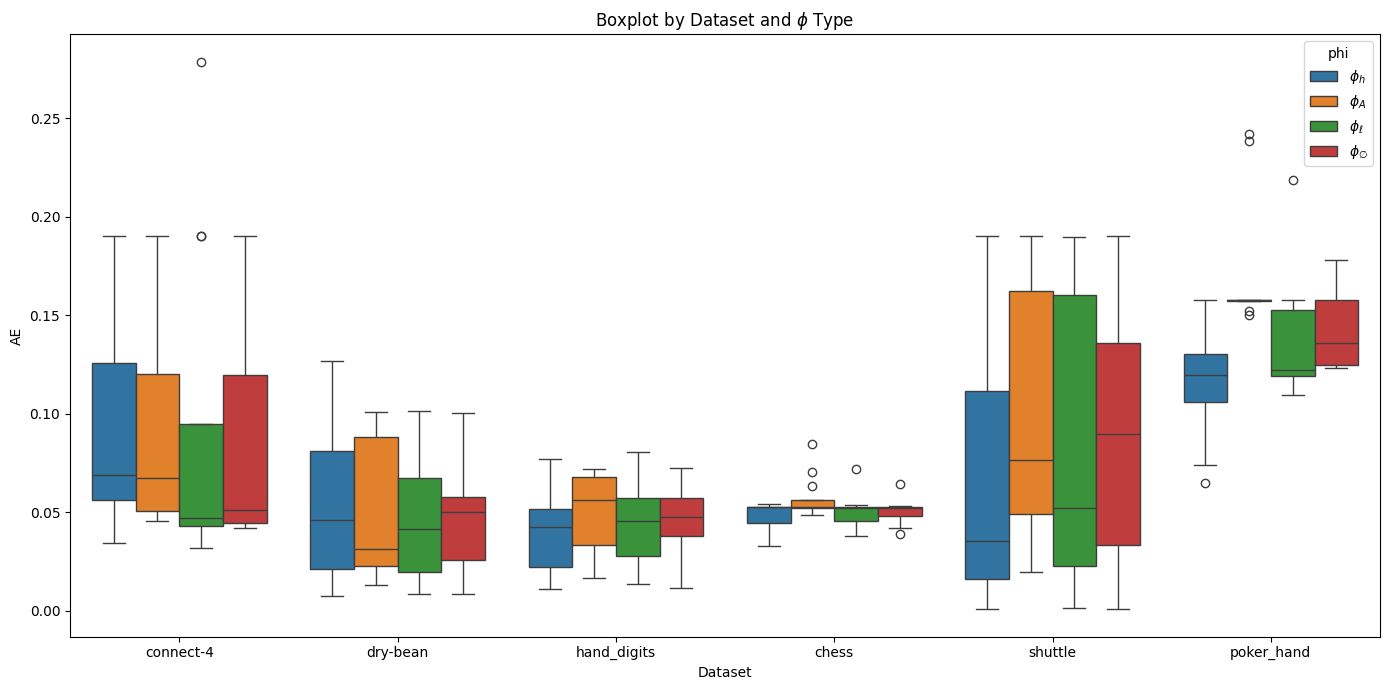

In [13]:

plt.figure(figsize=(14, 7))
sns.boxplot(x='Benchmark', y='Value', hue='phi', data=df_data)
plt.title(r'Boxplot by Dataset and $\phi$ Type')
plt.xlabel('Dataset')
plt.ylabel('AE')
plt.tight_layout()
plt.show()

Loss + Phi

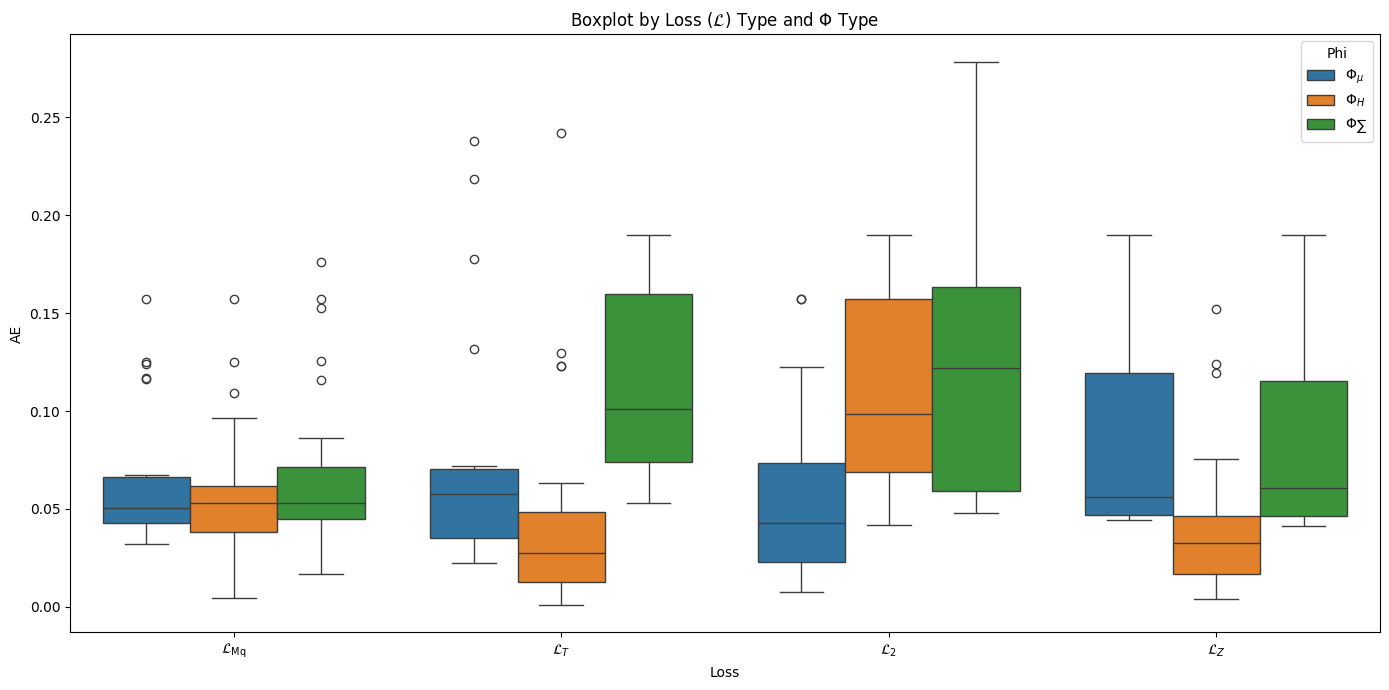

In [14]:

plt.figure(figsize=(14, 7))
sns.boxplot(x='Loss', y='Value', hue='Phi', data=df_data)
plt.title(r'Boxplot by Loss ($\mathcal{L}$) Type and $\Phi$ Type ')
plt.xlabel('Loss')
plt.ylabel('AE')
plt.tight_layout()
plt.show()

Loss + phi

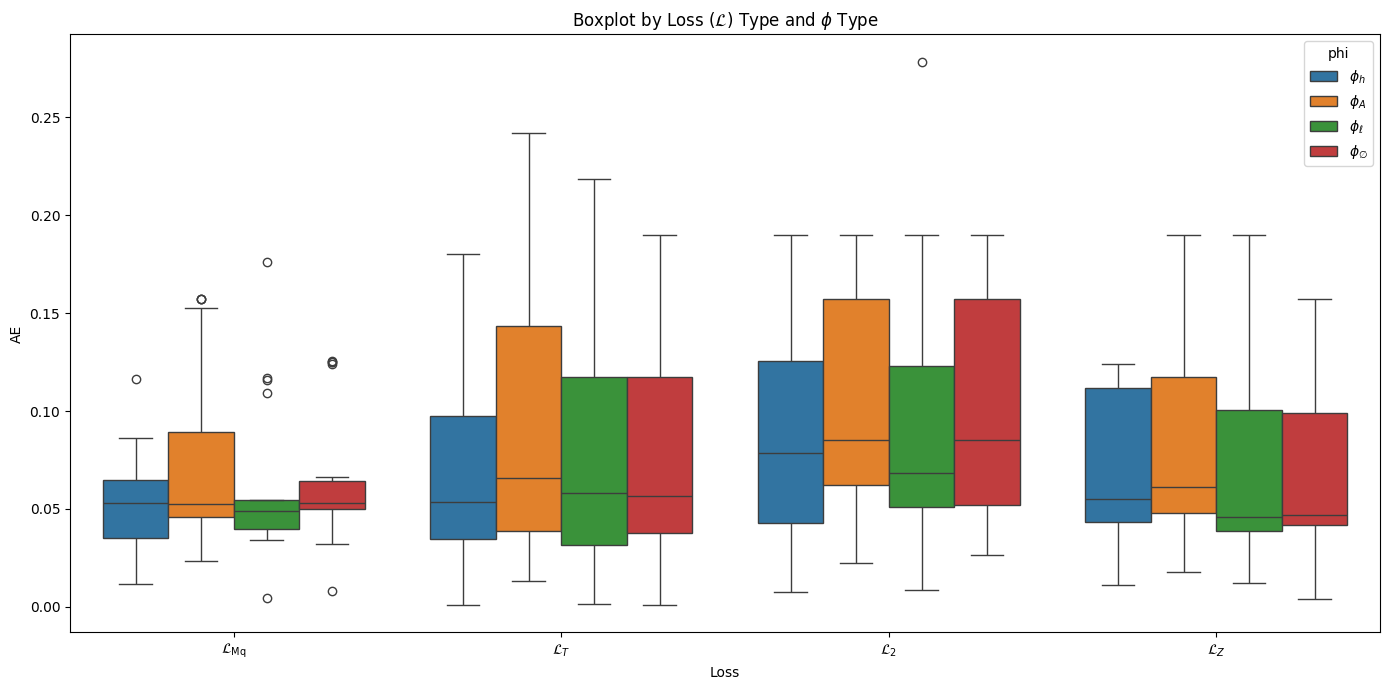

In [15]:

plt.figure(figsize=(14, 7))
sns.boxplot(x='Loss', y='Value', hue='phi', data=df_data)
plt.title(r'Boxplot by Loss ($\mathcal{L}$) Type and $\phi$ Type')
plt.xlabel('Loss')
plt.ylabel('AE')
plt.tight_layout()
plt.show()

Phi + phi

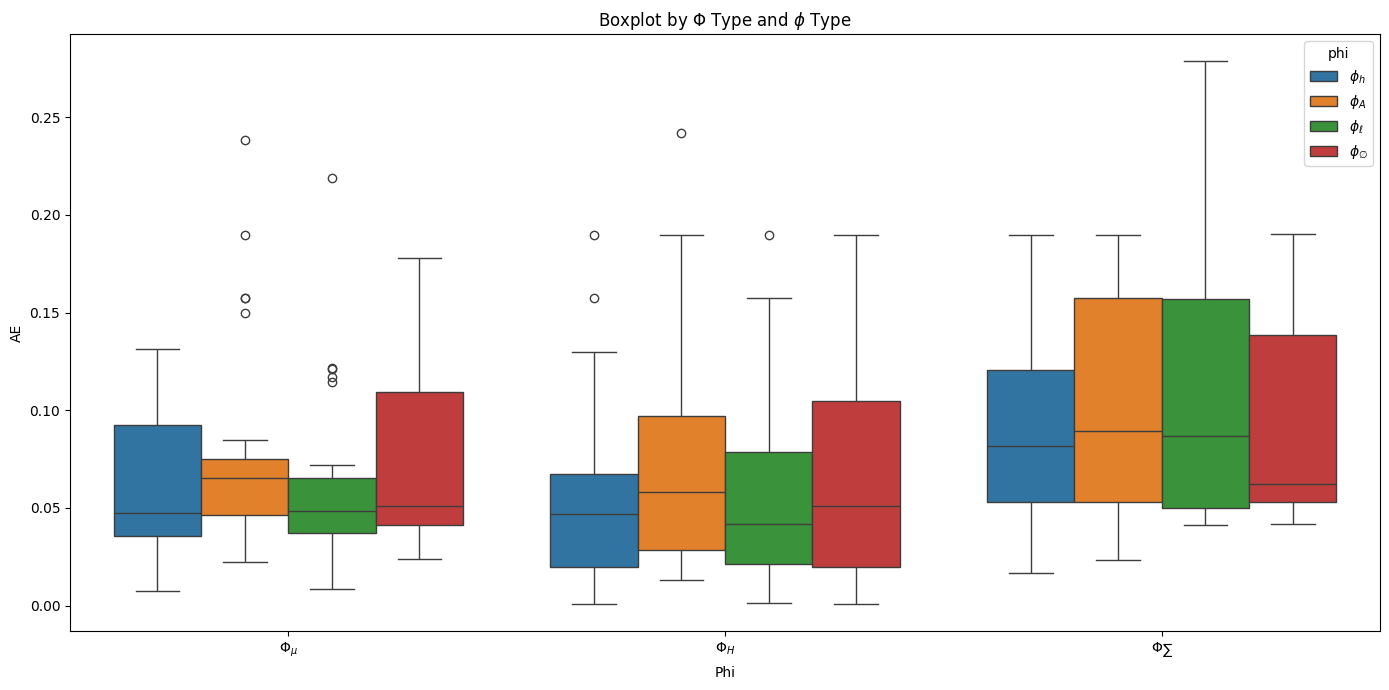

In [16]:

plt.figure(figsize=(14, 7))
sns.boxplot(x='Phi', y='Value', hue='phi', data=df_data)
plt.title(r'Boxplot by $\Phi$ Type and $\phi$ Type')
plt.xlabel('Phi')
plt.ylabel('AE')
plt.tight_layout()
plt.show()